In [3]:
import kagglehub

# Load the latest version
file_path = kagglehub.dataset_download(
  "algozee/teenager-menthal-healy",
)

100%|██████████| 15.8k/15.8k [00:00<00:00, 11.9MB/s]

Extracting files...


### Reading Dataset

In [72]:
import pandas as pd
import numpy as np
import os

df = pd.read_csv(os.path.join(file_path, "Teen_Mental_Health_Dataset.csv"))
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [ ]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [54]:
columns_to_check = [col for col in df.columns if ((df[col].dtype == 'str') or (df[col].dtype == 'int64'))]

for col in columns_to_check:
    unique_values = df[col].value_counts()
    print(f"------------------------\n{unique_values}")

------------------------
age
13    200
15    180
18    172
17    170
16    163
19    162
14    153
Name: count, dtype: int64
------------------------
gender
male      615
female    585
Name: count, dtype: int64
------------------------
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64
------------------------
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64
------------------------
stress_level
4     139
1     134
5     129
10    128
9     122
3     116
6     114
2     108
7     106
8     104
Name: count, dtype: int64
------------------------
anxiety_level
6     132
4     131
10    131
8     130
9     124
3     123
2     110
7     109
1     105
5     105
Name: count, dtype: int64
------------------------
addiction_level
6     134
8     132
7     124
2     120
9     118
4     117
3     117
10    115
5     114
1     109
Name: count, dtype: int64
------------------------
depression_label
0    1169
1     

### Data Visualization

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

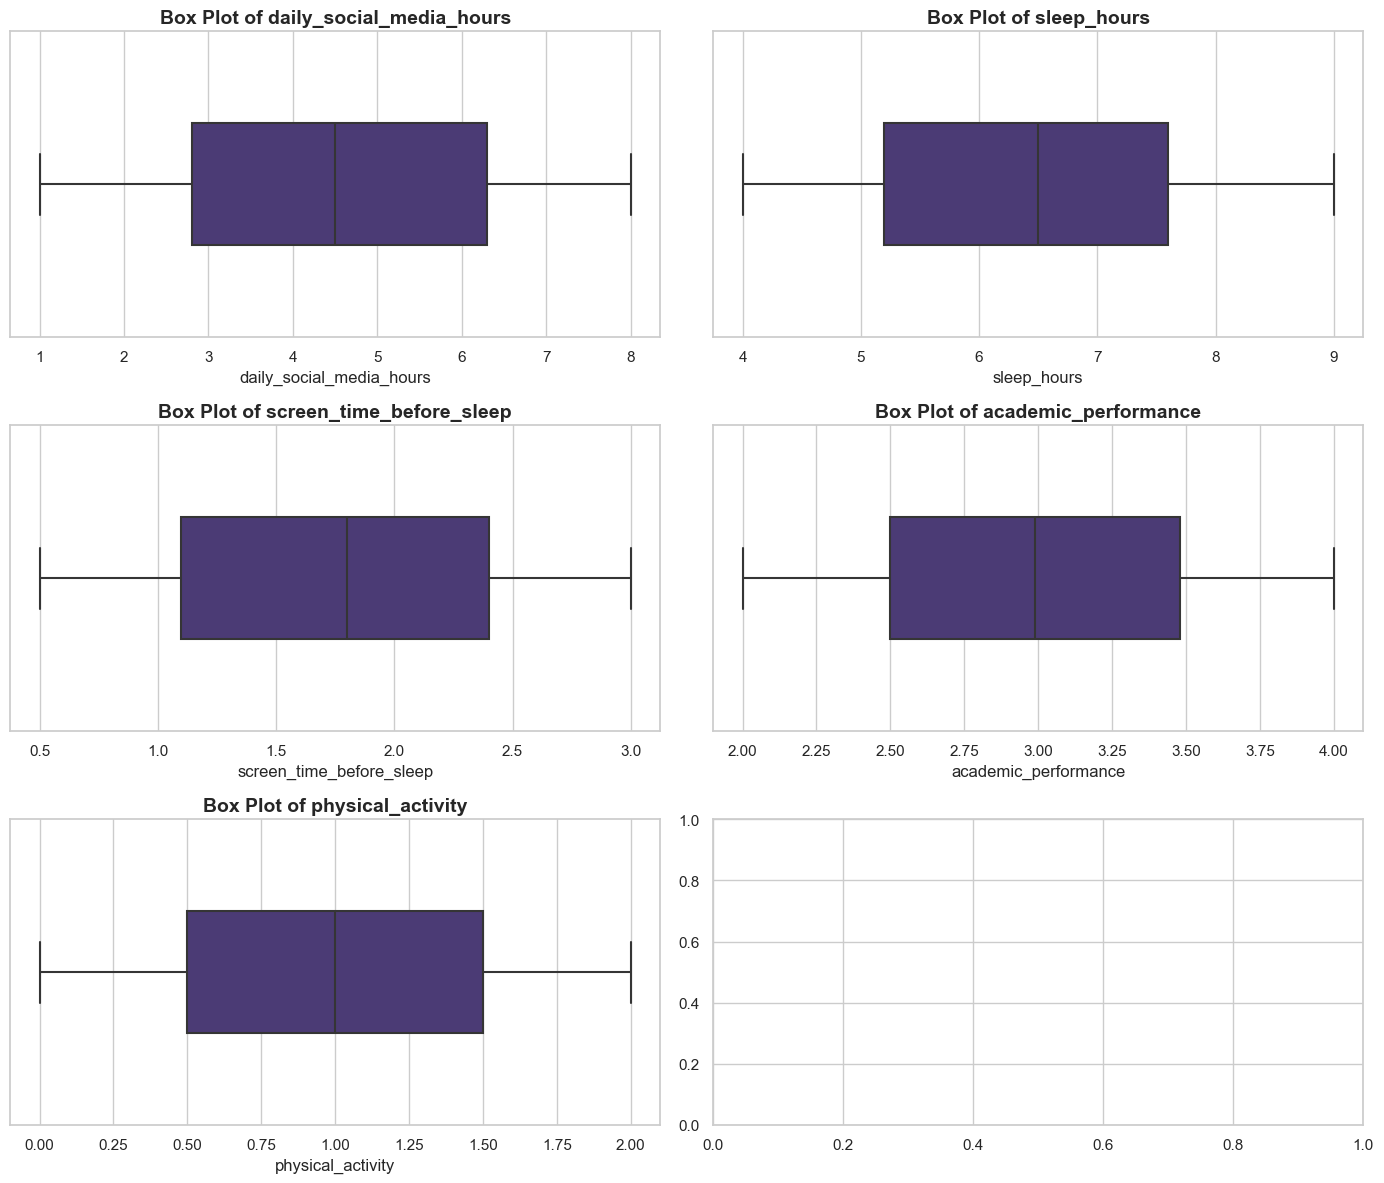

In [68]:
# Select numeric columns
num_cols = df.select_dtypes(include=['float64']).columns

# Set style
sns.set_theme(style="whitegrid", palette="viridis")

# Grid settings
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

# Handle case when only one column exists
if len(num_cols) == 1:
    axes = [axes]

# Plot boxplots
for ax, col in zip(axes, num_cols):
    sns.boxplot(
        x=df[col],
        ax=ax,
        width=0.4,
        fliersize=4,
        linewidth=1.5
    )
    
    ax.set_title(f"Box Plot of {col}", fontsize=14, weight='bold')
    ax.set_xlabel(col, fontsize=12)

plt.tight_layout()
plt.show()

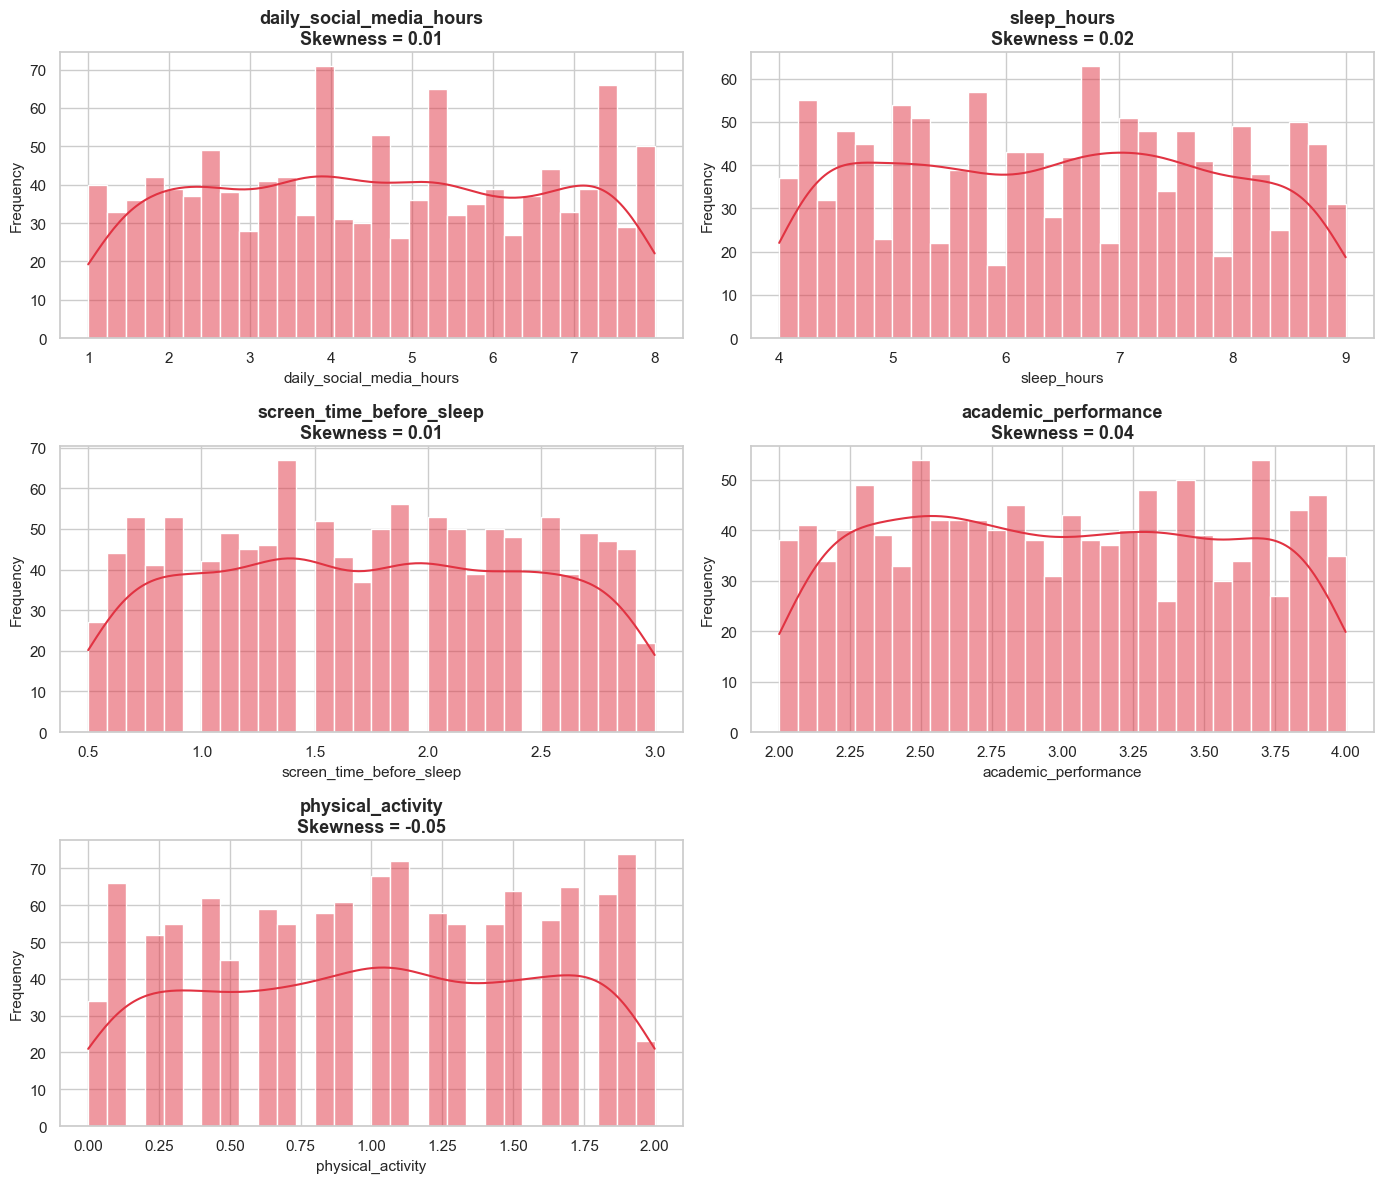

In [74]:
# Select numeric columns
num_cols = df.select_dtypes(include=['float64']).columns

# Set style
sns.set_theme(style="whitegrid", palette="crest")

# Grid settings
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

# Plot line charts
for ax, col in zip(axes, num_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30,
        ax=ax,
        color=sns.color_palette("rocket")[3]
    )

    skewness = np.round(df[col].skew(), 2)

    ax.set_title(
        f"{col}\nSkewness = {skewness}",
        fontsize=13,
        weight='bold'
    )

    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)

# Remove empty subplots
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

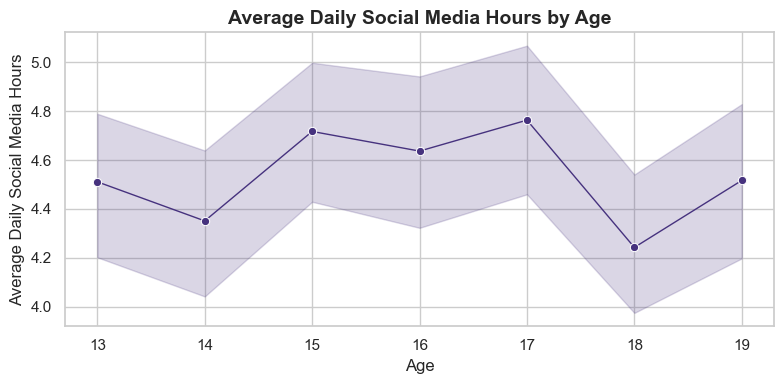

In [77]:
# Set style
sns.set_theme(style="whitegrid", palette="viridis")

# Create figure
plt.figure(figsize=(8, 4))

# Plot average social media hours by age
sns.lineplot(
    data=df,
    x="age",
    y="daily_social_media_hours",
    estimator="mean",
    marker="o",
    linewidth=1
)

# Titles and labels
plt.title("Average Daily Social Media Hours by Age", fontsize=14, weight='bold')
plt.xlabel("Age", fontsize=12)
plt.ylabel("Average Daily Social Media Hours", fontsize=12)

plt.tight_layout()
plt.show()

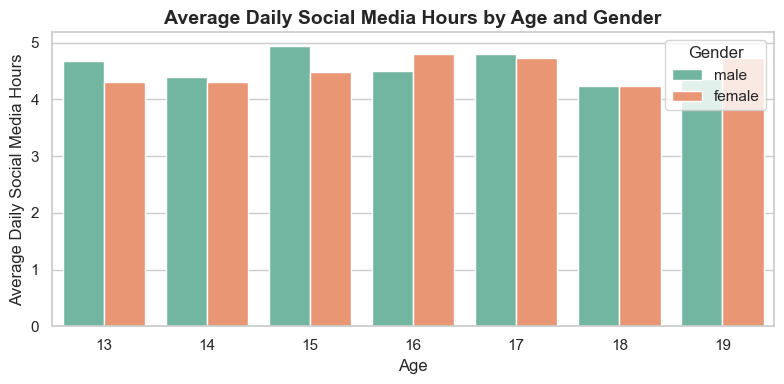

In [79]:
# Set style
sns.set(style="whitegrid", palette="Set2")

# Create figure
plt.figure(figsize=(8, 4))

# Grouped bar chart
sns.barplot(
    data=df,
    x="age",
    y="daily_social_media_hours",
    hue="gender",
    estimator="mean",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

# Titles and labels
plt.title("Average Daily Social Media Hours by Age and Gender", fontsize=14, weight='bold')
plt.xlabel("Age", fontsize=12)
plt.ylabel("Average Daily Social Media Hours", fontsize=12)

plt.legend(title="Gender")
plt.tight_layout()
plt.show()

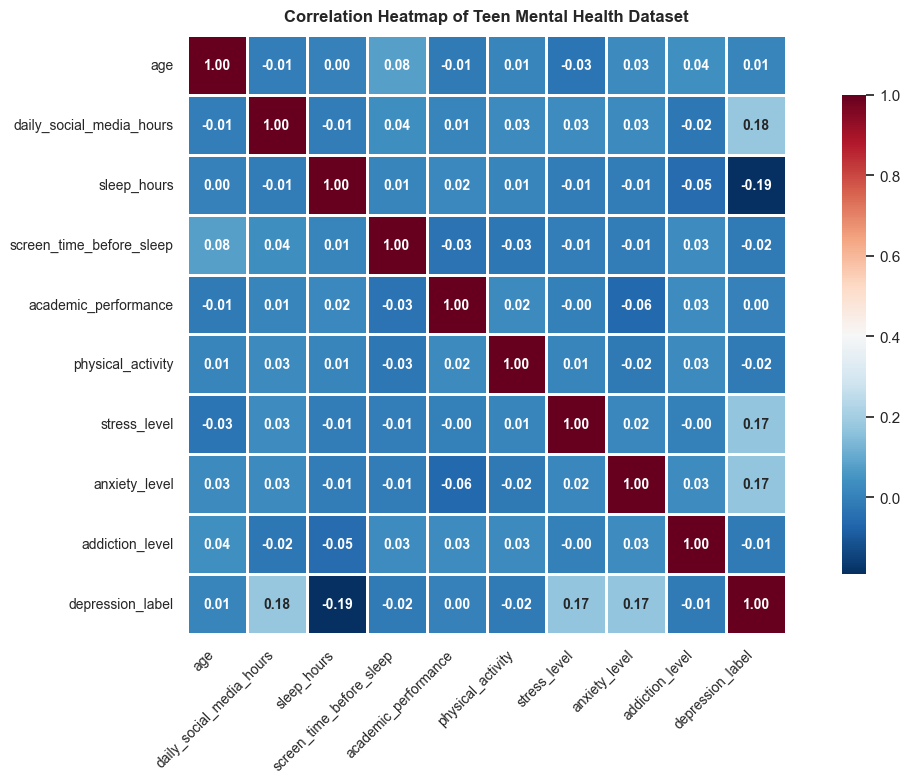

In [94]:
# Select numeric columns
columns_to_check = df.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation matrix
corr_matrix = df[columns_to_check].corr()

# Set theme
sns.set_theme(style="white")

# Create figure
plt.figure(figsize=(12, 8))

# Draw heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    linewidths=0.8,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10, "weight": "bold"}
)

# Titles
plt.title(
    "Correlation Heatmap of Teen Mental Health Dataset",
    fontsize=12,
    weight='bold',
    pad=10
)

# Rotate labels
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Tight layout
plt.tight_layout()

plt.show()

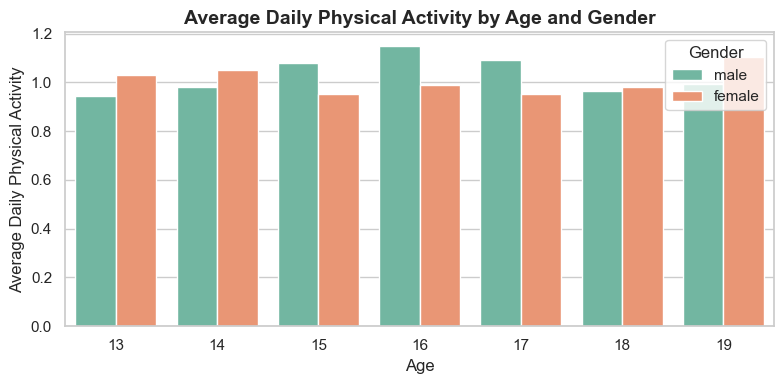

In [95]:
# Set style
sns.set(style="whitegrid", palette="Set2")

# Create figure
plt.figure(figsize=(8, 4))

# Grouped bar chart
sns.barplot(
    data=df,
    x="age",
    y="physical_activity",
    hue="gender",
    estimator="mean",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

# Titles and labels
plt.title("Average Daily Physical Activity by Age and Gender", fontsize=14, weight='bold')
plt.xlabel("Age", fontsize=12)
plt.ylabel("Average Daily Physical Activity", fontsize=12)

plt.legend(title="Gender")
plt.tight_layout()
plt.show()

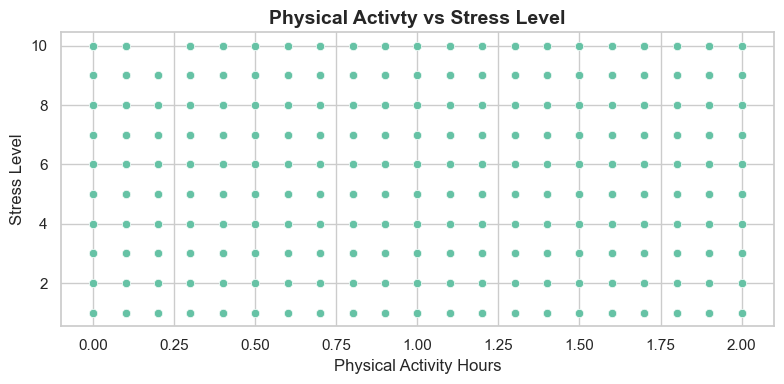

In [108]:
# Set style
sns.set(style="whitegrid", palette="Set2")

# Create figure
plt.figure(figsize=(8, 4))

# Grouped bar chart
sns.scatterplot(
    data=df,
    x="physical_activity",
    y="stress_level",
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

# Titles and labels
plt.title("Physical Activty vs Stress Level", fontsize=14, weight='bold')
plt.xlabel("Physical Activity Hours", fontsize=12)
plt.ylabel("Stress Level", fontsize=12)

plt.tight_layout()
plt.show()

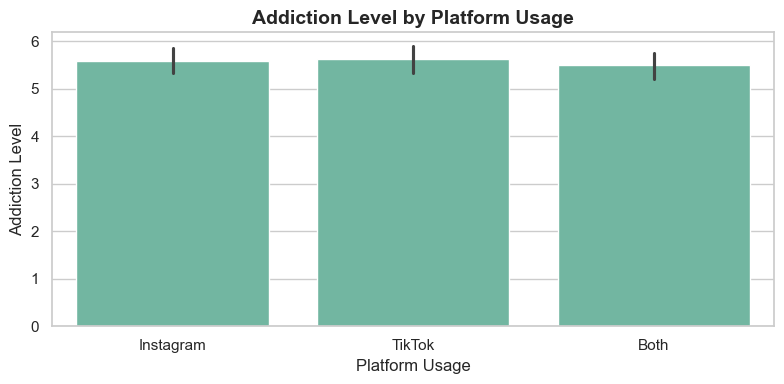

In [111]:
# Set style
sns.set_theme(style="whitegrid", palette="Set2")

# Create figure
plt.figure(figsize=(8, 4))

# Grouped bar chart
sns.barplot(
    data=df,
    x="platform_usage",
    y="addiction_level",
    estimator="mean",
    
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

# Titles and labels
plt.title("Addiction Level by Platform Usage", fontsize=14, weight='bold')
plt.xlabel("Platform Usage", fontsize=12)
plt.ylabel("Addiction Level", fontsize=12)

plt.tight_layout()
plt.show()

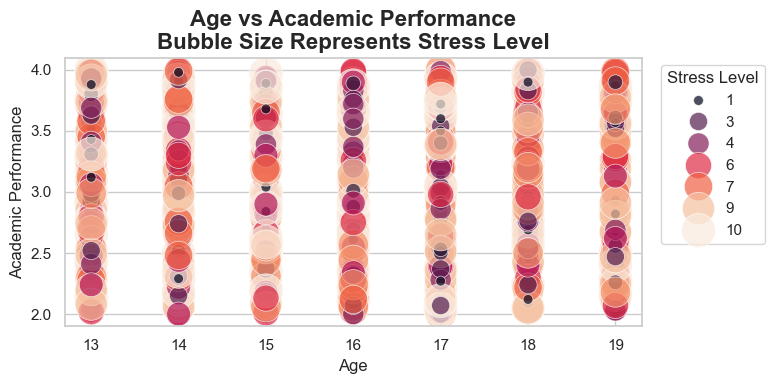

In [115]:
# Set style
sns.set(style="whitegrid", palette="viridis")

# Create figure
plt.figure(figsize=(8, 4))

# Grouped bar chart
# Bubble chart
sns.scatterplot(
    data=df,
    x="age",
    y="academic_performance",
    size="stress_level",
    hue="stress_level",
    sizes=(50, 600),
    alpha=0.7,
    palette="rocket"
)

# Titles and labels
plt.title(
    "Age vs Academic Performance\nBubble Size Represents Stress Level",
    fontsize=16,
    weight='bold'
)

plt.xlabel("Age", fontsize=12)
plt.ylabel("Academic Performance", fontsize=12)

# Legend
plt.legend(title="Stress Level", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

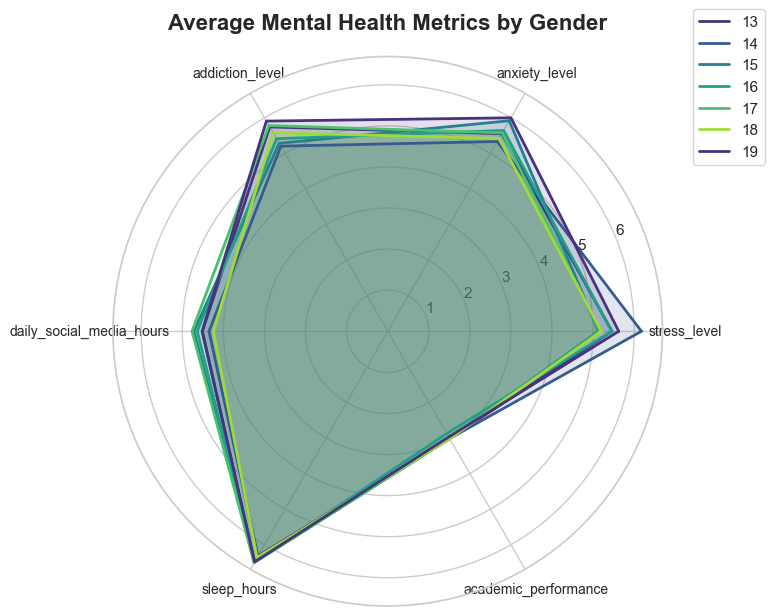

In [117]:
# Metrics to compare
metrics = [
    "stress_level",
    "anxiety_level",
    "addiction_level",
    "daily_social_media_hours",
    "sleep_hours",
    "academic_performance"
]

# Group by gender and calculate mean
radar_df = df.groupby("age")[metrics].mean()

# Number of variables
labels = metrics
num_vars = len(labels)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Create figure
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each gender
for gender in radar_df.index:
    values = radar_df.loc[gender].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=gender)
    ax.fill(angles, values, alpha=0.15)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)

# Title
plt.title(
    "Average Mental Health Metrics by Gender",
    fontsize=16,
    weight='bold',
    pad=20
)

# Legend
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()

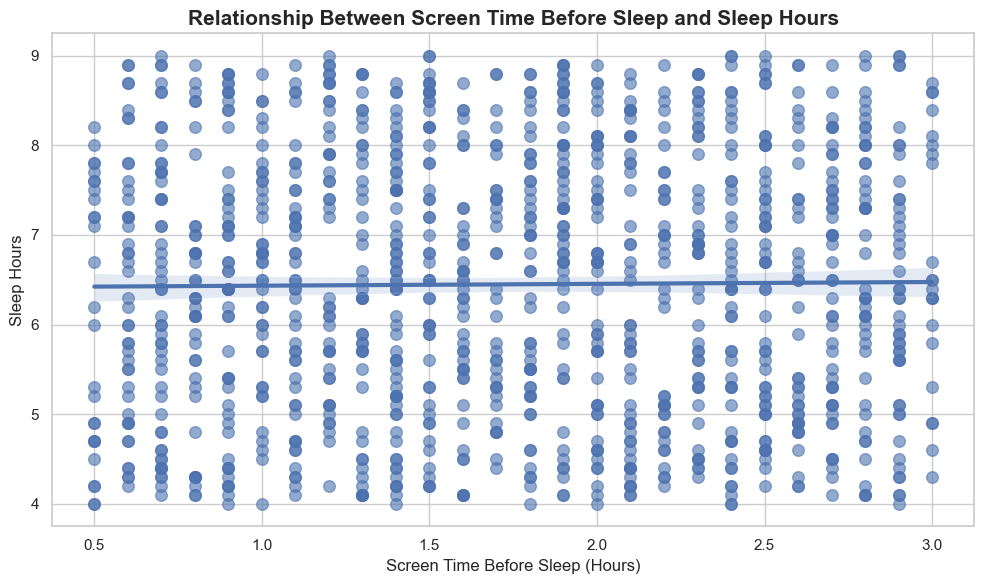

In [118]:
# Set style
sns.set(style="whitegrid", palette="deep")

# Create figure
plt.figure(figsize=(10, 6))

# Regression plot
sns.regplot(
    data=df,
    x="screen_time_before_sleep",
    y="sleep_hours",
    scatter_kws={
        "alpha": 0.6,
        "s": 70
    },
    line_kws={
        "linewidth": 3
    }
)

# Titles and labels
plt.title(
    "Relationship Between Screen Time Before Sleep and Sleep Hours",
    fontsize=15,
    weight='bold'
)

plt.xlabel("Screen Time Before Sleep (Hours)", fontsize=12)
plt.ylabel("Sleep Hours", fontsize=12)

plt.tight_layout()
plt.show()

c:\Users\darsh\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 45.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\darsh\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 29.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\darsh\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 38.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\darsh\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 32.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(ms

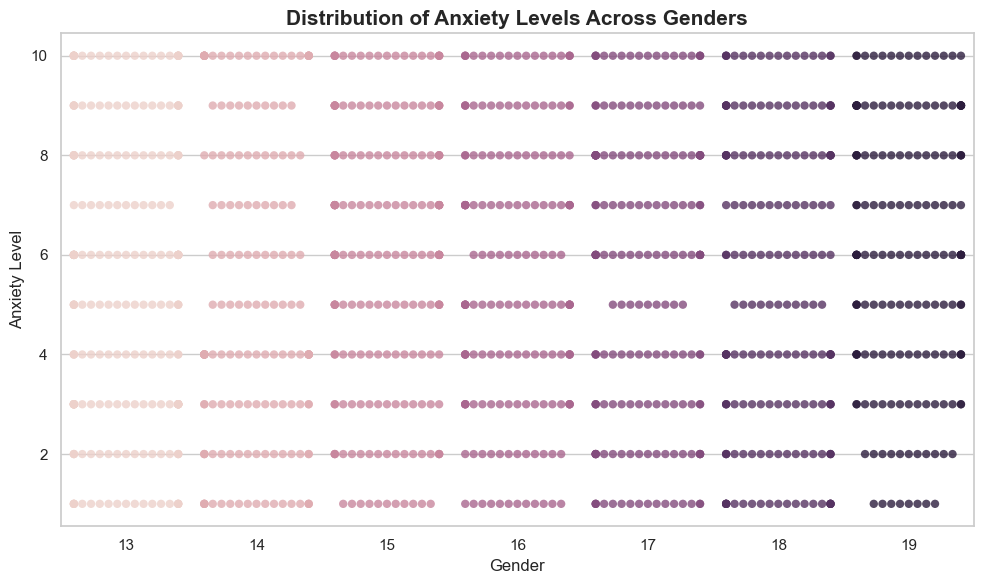

In [121]:
# Set style
sns.set(style="whitegrid", palette="Set2")

# Create figure
plt.figure(figsize=(10, 6))

# Swarm plot
sns.swarmplot(
    data=df,
    x="age",
    y="anxiety_level",
    hue="age",
    size=6,
    alpha=0.8
)

# Titles and labels
plt.title(
    "Distribution of Anxiety Levels Across Genders",
    fontsize=15,
    weight='bold'
)

plt.xlabel("Gender", fontsize=12)
plt.ylabel("Anxiety Level", fontsize=12)

# Remove duplicate legend
plt.legend([], [], frameon=False)

plt.tight_layout()
plt.show()

<h4>Conclusion</h4>
The analysis indicates that social media usage patterns are consistently high across all teenage age groups, suggesting that social media addiction is no longer limited to a specific age segment but has become a shared behavioral trend among teens.

The dataset also reveals similar lifestyle patterns across ages, including reduced sleep hours, moderate academic performance, and elevated levels of stress, anxiety, and addiction. These patterns collectively point toward a growing imbalance between digital engagement and overall well-being.

Although the severity may vary slightly among individuals, the overall trends suggest that excessive social media usage is contributing to mental and emotional strain across the teenage population. The findings highlight the importance of promoting healthier digital habits, better sleep routines, and stronger mental health awareness to prevent long-term psychological impacts on teens.